In [1]:
import CoolProp.CoolProp as CP
import numpy as np
from devito import *

# %matplotlib inline

# Coeficientes
i = 32 * np.pi/180  #Latitude
S = 37 * np.pi/180  #Angulo do coletor
n = 200   #Dia do ano
k_g = 5.9 #Condutividade Térmica do Vidro
C_g = 753 #Calor específico do vidro
ro_g = 2.466  #Densidade do Vidro
delta_g = 4e-3  #Espessura do vidro
l_p = 2 #Largura do Vidro
ro_a = 1.09 #Densidade do ar
k_a = 0.025 #Condutividade do ar
C_a = 1005  #Calor específico do ar
alpha_g = 0.1 #Coeficiente de absorvição do ar
alpha_p = 0.96  #Coeficiente de absorvição da placa
tau_g = 0.8 #Coeficiente transiente do vidro
C_p = 900 #Calor específico da placa
ro_w = 1000 #Densidade da água
L = 2 #Largura do coletor
b = 1 #Comprimento do coletor
ro_d = 960 #Densidade do material seco
a = 0.1 #Altura do duto coletor
k_p = 250 #Condutividade térmica da placa
M_0 = 3.5 #Conteúdo úmido inicial
sigma = 5.57e-8
A_C = b * L #Área do coletor
epslon_p = 1 #Emitancia, como é um corpo negro, é 1
VelocidadeAr = 1 #Pode ser alterada

# ADICIONADO: Densidade da placa (kg/m³), supondo que ela seja de alumínio
ro_p = 2700 

# ADICIONADO Pressão atmosférica (Pa)
P_atm = 101325

In [2]:
#import ay_eq_radiacao
# Radiação solar total fixa pra testar inicialmente:
It = 800.0

In [3]:
# time grid
from examples.seismic.source import Receiver, TimeAxis
t0 = 0
tn = 86400
dt = 300
nt = int((tn-t0)/dt) # de meia em meia hora

time_range = TimeAxis(start=t0,stop=tn,num=nt+1)

In [4]:
# grid e Temperaturas
grid_v = Grid(shape=(10), extent=(1.))
grid_p = Grid(shape=(10), extent=(1.))
grid_a = Grid(shape=(10), extent=(1.))

TemperaturaVidro = TimeFunction(name='T_g', grid=grid_v, space_order=2)
TemperaturaPlaca = TimeFunction(name='T_p', grid=grid_p, space_order=2)
TemperaturaAr = TimeFunction(name='T_a', grid=grid_a, space_order=2)

#Usando o grid do vidro, mas a temperatura ambiente deve ser uniforme ao longo do grid espacial
TemperaturaAmbiente = TimeFunction(name='T_am', grid=grid_v, space_order=2)

# Termos dependentes das temperaturas
TemperaturaCeu = 0.0552*(TemperaturaAmbiente**1.5)

# MODIFICADO (CoolProp precisa da pressão, tava faltando isso antes)
# E ele precisa de temperatura de referência, em Kelvin:
T_ref = 300.0
viscosidadeDinamica = CP.PropsSI("V", "T", T_ref, "P", P_atm, "Air")
calorEspecifico = CP.PropsSI("CPMASS", "T", T_ref, "P", P_atm, "Air")
condutividadeTermica = CP.PropsSI("CONDUCTIVITY", "T", T_ref, "P", P_atm, "Air")


In [ ]:


"""
 Para definir h_pa, h_ga e h_gam
 precisa definir o número de Reynolds e o número de Prandtl
"""

Re = ro_a * VelocidadeAr * L / viscosidadeDinamica
Pr = calorEspecifico * viscosidadeDinamica / condutividadeTermica

# Nu = Número de Nusselt
if Re * Pr * a/L > 70:
    Nu = 7.6
else:
    Nu = 1.85*pow(Re * Pr * a / L, 1/3)

h_ga = Nu * k_a / L
h_pa = h_ga

Nu_gam = 0.86 * pow(Re, 0.5) * pow(Pr, 1/3)
h_gam = Nu_gam * k_a / L

h_rpsky = sigma * (TemperaturaPlaca**2 + TemperaturaCeu**2) * \
          (TemperaturaPlaca + TemperaturaCeu)/(1/epslon_p + 1/tau_g - 1)

# ADICIONADO (tava como comentário)
h_rpg = sigma * (TemperaturaPlaca**2 + TemperaturaVidro**2) * \
        (TemperaturaPlaca + TemperaturaVidro)/(1/epslon_p + 1/tau_g - 1)

In [5]:
# Equações Diferenciais
eq11 = Eq(TemperaturaVidro.dt,
          (k_g/(C_g*ro_g))*TemperaturaVidro.dx2
          + It*alpha_g/(ro_g*C_g*delta_g))

eq12 = Eq(TemperaturaPlaca.dt,
          It*tau_g*alpha_p/(ro_p*C_p*l_p)
          + (h_pa/(ro_p*C_p*l_p))*(TemperaturaAr - TemperaturaPlaca)
          - (h_rpsky/(ro_p*C_p*l_p)) * (TemperaturaPlaca - TemperaturaCeu)
          - (h_rpg/(ro_p*C_p*l_p)) * (TemperaturaPlaca - TemperaturaVidro))

eq13 = Eq(TemperaturaAr.dt,
          (-1) * VelocidadeAr * TemperaturaAr.dx
          + (h_ga*b/(ro_a*C_a*A_C))*(TemperaturaVidro-TemperaturaAr)
          + (h_pa*b/(ro_p*C_p*A_C))*(TemperaturaPlaca-TemperaturaAr))

eq_1 = Eq(TemperaturaVidro.forward, solve(eq11, TemperaturaVidro.forward))
eq_2 = Eq(TemperaturaPlaca.forward, solve(eq12, TemperaturaPlaca.forward))
eq_3 = Eq(TemperaturaAr.forward, solve(eq13, TemperaturaAr.forward))

In [6]:
nrec = 1

rec_T = Receiver(name="rec_T", grid=grid_a, npoint=nrec, time_range=time_range)
rec_T.coordinates.data[:, 0] = 0.5

rec_term = rec_T.interpolate(expr=TemperaturaAr.forward)

In [7]:
op = Operator([eq_1, eq_2, eq_3] + rec_term)

In [8]:
op(dt=dt, time=nt)

Operator `Kernel` ran in 0.01 s


PerformanceSummary([(PerfKey(name='section0', rank=None),
                     PerfEntry(time=1e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[])),
                    (PerfKey(name='section1', rank=None),
                     PerfEntry(time=1e-06, gflopss=0.0, gpointss=0.0, oi=0.0, ops=0, itershapes=[]))])

In [9]:
import matplotlib.pyplot       as plt
import matplotlib.ticker       as mticker    
from   mpl_toolkits.axes_grid1 import make_axes_locatable
from   matplotlib              import cm
from   matplotlib              import ticker

# Plot Configuration
#==============================================================================
plt.rc('text' , usetex=True)
plt.rc('font' , family='serif')
plt.rc('xtick', labelsize=20) 
plt.rc('ytick', labelsize=20)

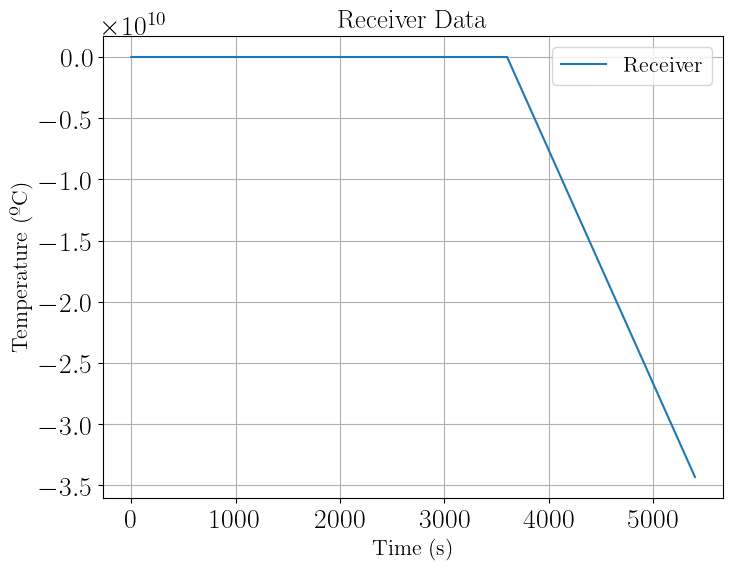

In [10]:
plt.plot(time_range.time_values, rec_T.data, label=f"Receiver")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (ºC)")
plt.title("Receiver Data")
plt.legend()
plt.grid()
plt.show()